# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


In [191]:
# Install required libraries
!pip install wordcloud xgboost nltk scikit-learn matplotlib seaborn pandas numpy -q

In [192]:
# Q1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split, cross_val_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [193]:
# Q1: Load Dataset
# Load stsa-train.txt — format: 'label<space>text'
def load_stsa(filepath):
    labels, texts = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                label = int(line[0])
                text  = line[2:].strip()
                labels.append(label)
                texts.append(text)
    return pd.DataFrame({'text': texts, 'label': labels})

df_q1 = load_stsa('stsa-train.txt')
print(f"Dataset shape: {df_q1.shape}")
print(f"\nFirst 5 rows:")
df_q1.head()

Dataset shape: (6920, 2)

First 5 rows:


,text,label
0,"a stirring , funny and finally transporting re...",1
1,apparently reassembled from the cutting-room f...,0
2,they presume their audience wo n't sit still f...,0
3,this is a visually stunning rumination on love...,1
4,jonathan parker 's bartleby should have been t...,1


Class Distribution:
label
1    3610
0    3310
Name: count, dtype: int64

Positive: 3610 (52.2%)
Negative: 3310 (47.8%)


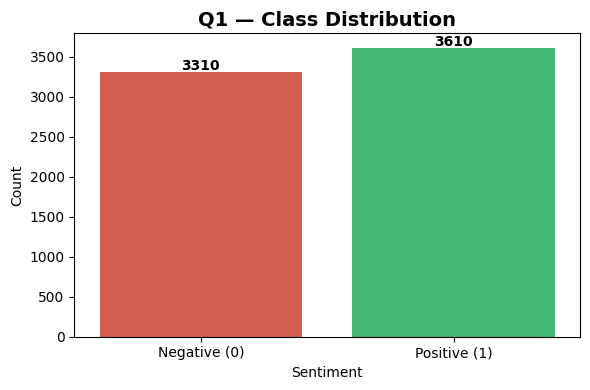

The dataset is relatively balanced — no oversampling needed.


In [194]:
# Q1: EDA — Class Distribution
label_counts = df_q1['label'].value_counts()
print("Class Distribution:")
print(label_counts)
print(f"\nPositive: {label_counts[1]} ({label_counts[1]/len(df_q1)*100:.1f}%)")
print(f"Negative: {label_counts[0]} ({label_counts[0]/len(df_q1)*100:.1f}%)")

plt.figure(figsize=(6, 4))
sns.barplot(x=['Negative (0)', 'Positive (1)'],
            y=[label_counts[0], label_counts[1]],
            palette=['#E74C3C', '#2ECC71'])
plt.title('Q1 — Class Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xlabel('Sentiment')
for i, v in enumerate([label_counts[0], label_counts[1]]):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print("The dataset is relatively balanced — no oversampling needed.")

In [195]:
# Q1: Preprocessing — Tokenization, Stopword Removal, Lemmatization
import nltk
# Download ALL required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')       # ← THIS is what was missing
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df_q1['clean_text'] = df_q1['text'].apply(preprocess)
print("Preprocessing complete!")
print("\nOriginal:  ", df_q1['text'].iloc[0])
print("Cleaned:   ", df_q1['clean_text'].iloc[0])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Preprocessing complete!

Original:   a stirring , funny and finally transporting re-imagining of beauty and the beast and 1930s horror films
Cleaned:    stirring funny finally transporting reimagining beauty beast horror film


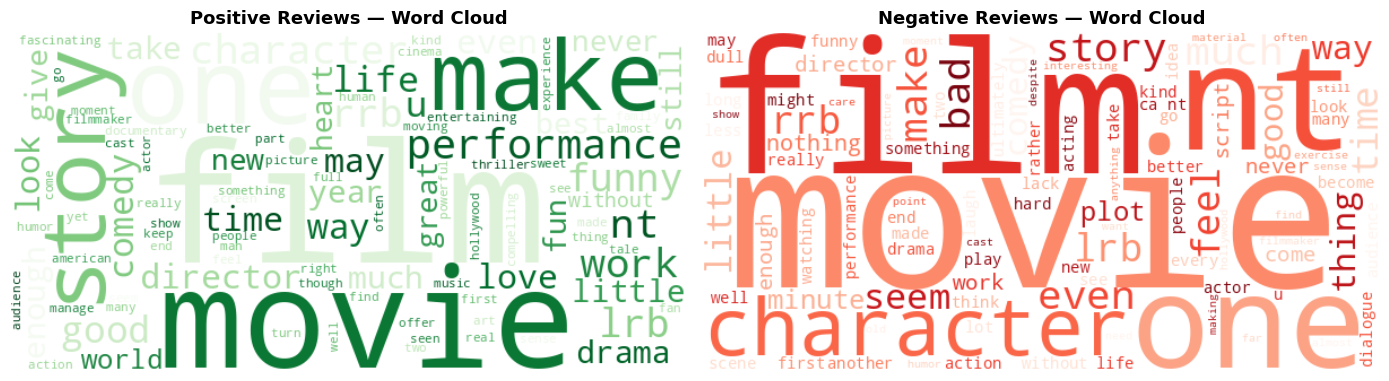

In [196]:
# Q1: EDA — Word Clouds
pos_text = ' '.join(df_q1[df_q1['label']==1]['clean_text'])
neg_text = ' '.join(df_q1[df_q1['label']==0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_pos = WordCloud(width=600, height=300, background_color='white',
                   colormap='Greens', max_words=100).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Reviews — Word Cloud', fontsize=13, fontweight='bold')

wc_neg = WordCloud(width=600, height=300, background_color='white',
                   colormap='Reds', max_words=100).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Reviews — Word Cloud', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

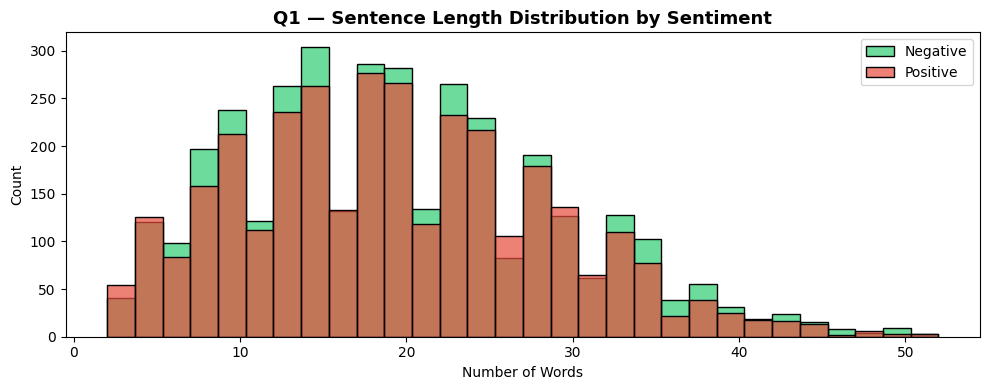

Average length — Positive: 19.4 words
Average length — Negative: 19.2 words


In [197]:
#  Q1: EDA — Sentence Length Analysis
df_q1['text_length'] = df_q1['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
sns.histplot(data=df_q1, x='text_length', hue='label', bins=30,
             palette={0: '#E74C3C', 1: '#2ECC71'}, alpha=0.7)
plt.title('Q1 — Sentence Length Distribution by Sentiment', fontsize=13, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.legend(['Negative', 'Positive'])
plt.tight_layout()
plt.show()

print(f"Average length — Positive: {df_q1[df_q1['label']==1]['text_length'].mean():.1f} words")
print(f"Average length — Negative: {df_q1[df_q1['label']==0]['text_length'].mean():.1f} words")

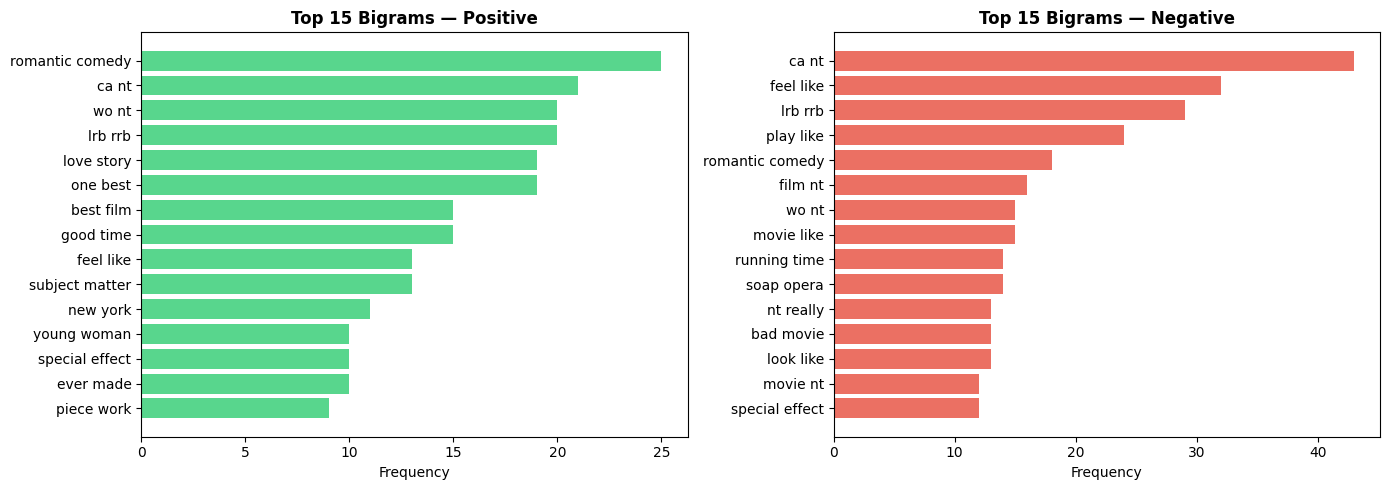

In [198]:
#  Q1: EDA — Top Bigrams
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), max_features=top_k).fit(corpus)
    bag = vec.transform(corpus)
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

pos_bigrams = get_top_ngrams(df_q1[df_q1['label']==1]['clean_text'])
neg_bigrams = get_top_ngrams(df_q1[df_q1['label']==0]['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, bigrams, title, color in zip(
    axes,
    [pos_bigrams, neg_bigrams],
    ['Top 15 Bigrams — Positive', 'Top 15 Bigrams — Negative'],
    ['#2ECC71', '#E74C3C']
):
    words, counts = zip(*bigrams)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

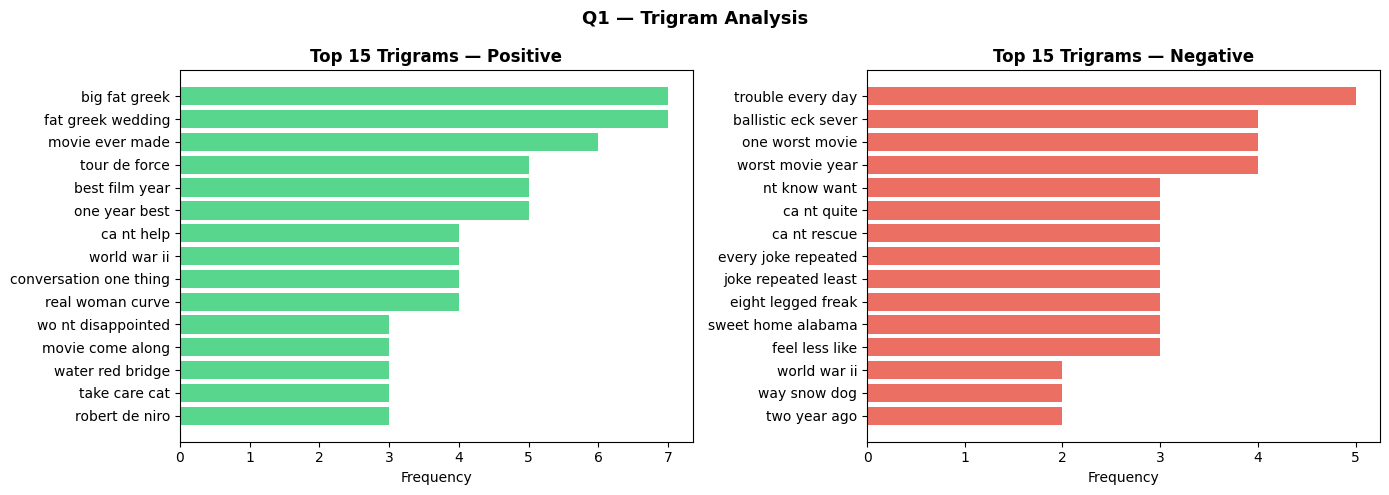

In [199]:
pos_trigrams = get_top_ngrams(df_q1[df_q1['label']==1]['clean_text'], n=3)
neg_trigrams = get_top_ngrams(df_q1[df_q1['label']==0]['clean_text'], n=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, trigrams, title, color in zip(
    axes,
    [pos_trigrams, neg_trigrams],
    ['Top 15 Trigrams — Positive', 'Top 15 Trigrams — Negative'],
    ['#2ECC71', '#E74C3C']
):
    words, counts = zip(*trigrams)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Q1 — Trigram Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [200]:
# Q1: Sentiment Classification — TF-IDF + 3 Models + Cross-Validation
X = df_q1['clean_text']
y = df_q1['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'SVM (LinearSVC)': LinearSVC(random_state=42, max_iter=2000),
    'Naive Bayes':     MultinomialNB(),
    'XGBoost':         XGBClassifier(random_state=42,
                                     use_label_encoder=False,
                                     eval_metric='logloss',
                                     n_estimators=100)
}

q1_results = {}
for name, model in models.items():
    # Cross Validation
    cv_scores = cross_val_score(model, X_train_tfidf, y_train,
                                cv=skf, scoring='accuracy')
    print(f'\n{"="*50}')
    print(f'Model: {name}')
    print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
    print(f'{"="*50}')

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    q1_results[name] = {
        'CV_Accuracy': cv_scores.mean(),
        'Accuracy':    accuracy_score(y_test, y_pred),
        'Precision':   precision_score(y_test, y_pred),
        'Recall':      recall_score(y_test, y_pred),
        'F1-Score':    f1_score(y_test, y_pred),
        'y_pred':      y_pred
    }
    print(classification_report(y_test, y_pred,
          target_names=['Negative','Positive']))

print('\nAll Q1 models trained with Cross-Validation!')


Model: SVM (LinearSVC)
5-Fold CV Accuracy: 0.7552 +/- 0.0120
              precision    recall  f1-score   support

    Negative       0.75      0.73      0.74       662
    Positive       0.76      0.78      0.77       722

    accuracy                           0.75      1384
   macro avg       0.75      0.75      0.75      1384
weighted avg       0.75      0.75      0.75      1384


Model: Naive Bayes
5-Fold CV Accuracy: 0.7746 +/- 0.0152
              precision    recall  f1-score   support

    Negative       0.77      0.69      0.73       662
    Positive       0.74      0.82      0.78       722

    accuracy                           0.75      1384
   macro avg       0.76      0.75      0.75      1384
weighted avg       0.76      0.75      0.75      1384


Model: XGBoost
5-Fold CV Accuracy: 0.6927 +/- 0.0100
              precision    recall  f1-score   support

    Negative       0.71      0.58      0.64       662
    Positive       0.67      0.78      0.72       722

    accu


Q1 — Model Comparison Table:
                 CV_Accuracy  Accuracy  Precision  Recall  F1-Score
SVM (LinearSVC)       0.7552    0.7536     0.7557  0.7798    0.7676
Naive Bayes           0.7746    0.7543     0.7393  0.8172    0.7763
XGBoost               0.6927    0.6879     0.6722  0.7839    0.7238


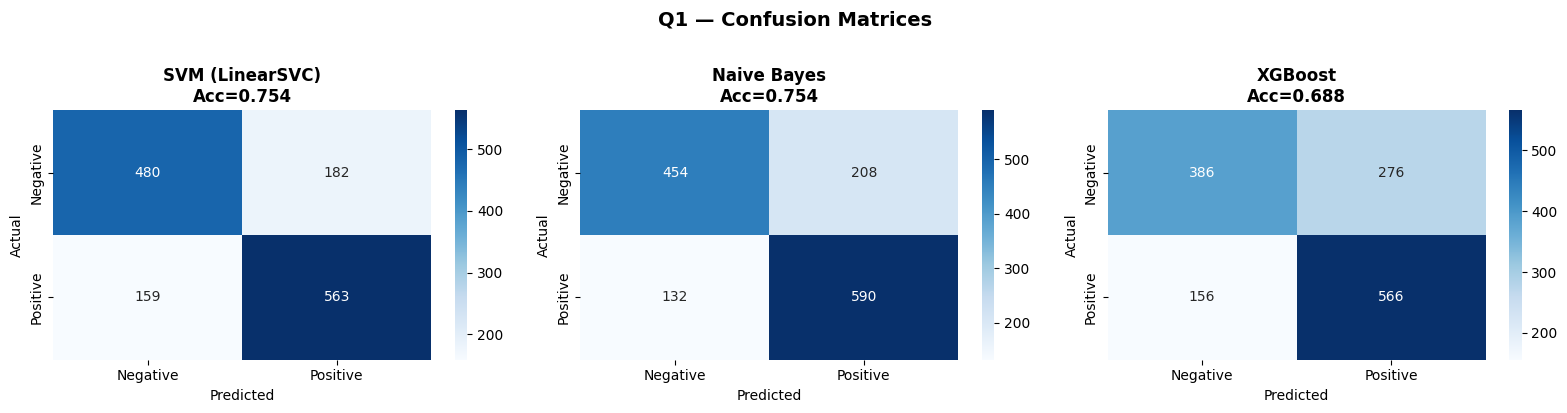

In [201]:
# Q1: Evaluation — Comparison Table & Confusion Matrices
results_df = pd.DataFrame({
    name: {k: round(v, 4) for k, v in metrics.items() if k != 'y_pred'}
    for name, metrics in q1_results.items()
}).T
print("\nQ1 — Model Comparison Table:")
print(results_df.to_string())

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, metrics) in zip(axes, q1_results.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative','Positive'],
                yticklabels=['Negative','Positive'])
    ax.set_title(f'{name}\nAcc={metrics["Accuracy"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Q1 — Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

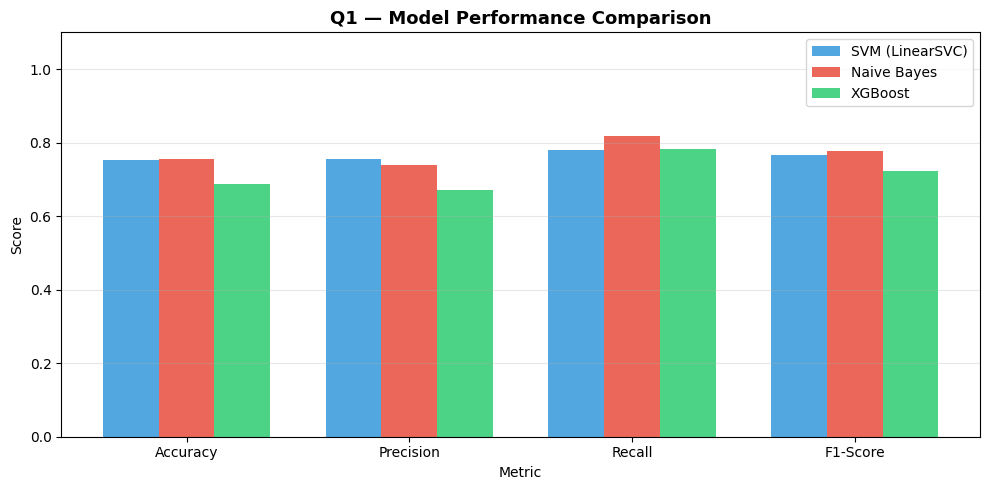


Best Model: Naive Bayes with F1-Score = 0.7763

Summary: Naive Bayes achieved the best F1-Score among the three models. SVM is well-suited for high-dimensional TF-IDF feature spaces. Naive Bayes is fast and effective for text classification. XGBoost is powerful but computationally heavier than the other two.


In [202]:
# Q1: Results Summary Bar Chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ['#3498DB', '#E74C3C', '#2ECC71']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, metrics) in enumerate(q1_results.items()):
    vals = [metrics[m] for m in metrics_to_plot]
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Q1 — Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best = results_df['F1-Score'].idxmax()
print(f'\nBest Model: {best} with F1-Score = {results_df.loc[best, "F1-Score"]:.4f}')
print(f'\nSummary: {best} achieved the best F1-Score among the three models. '
      f'SVM is well-suited for high-dimensional TF-IDF feature spaces. '
      f'Naive Bayes is fast and effective for text classification. '
      f'XGBoost is powerful but computationally heavier than the other two.')

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


In [203]:
#  Q2: Additional Imports
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

print("Q2 libraries ready!")


Q2 libraries ready!


In [204]:
#  Q2: Load Train and Test Datasets
df_train = load_stsa('stsa-train.txt')
df_test  = load_stsa('stsa-test.txt')

print(f"Training set shape : {df_train.shape}")
print(f"Test set shape     : {df_test.shape}")
print(f"\nTrain label distribution:")
print(df_train['label'].value_counts())
print(f"\nTest label distribution:")
print(df_test['label'].value_counts())

Training set shape : (6920, 2)
Test set shape     : (1821, 2)

Train label distribution:
label
1    3610
0    3310
Name: count, dtype: int64

Test label distribution:
label
0    912
1    909
Name: count, dtype: int64


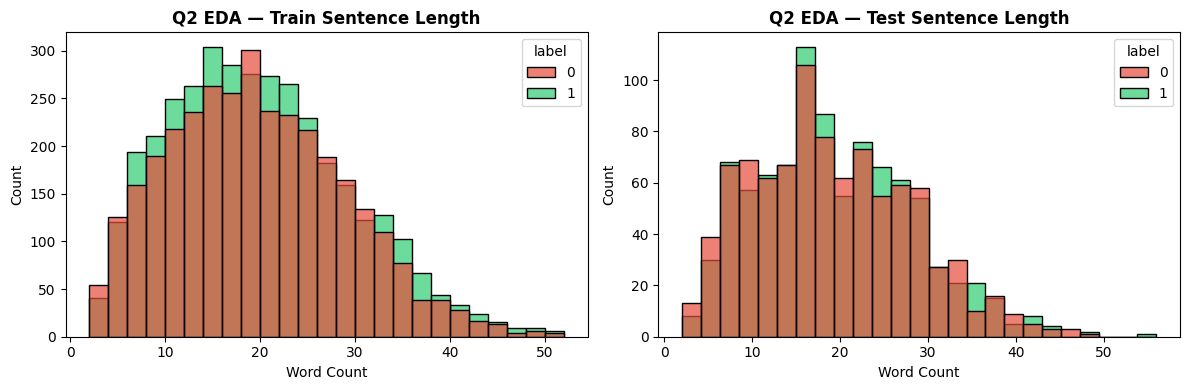

Train — avg length: 19.3 words
Test  — avg length: 19.2 words


In [205]:
#  Q2: EDA — Sentence Length Distribution
df_train['length'] = df_train['text'].apply(lambda x: len(x.split()))
df_test['length']  = df_test['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [df_train, df_test], ['Train', 'Test']):
    sns.histplot(data=df, x='length', hue='label', bins=25,
                 palette={0: '#E74C3C', 1: '#2ECC71'}, ax=ax, alpha=0.7)
    ax.set_title(f'Q2 EDA — {title} Sentence Length', fontweight='bold')
    ax.set_xlabel('Word Count')

plt.tight_layout()
plt.show()

print(f"Train — avg length: {df_train['length'].mean():.1f} words")
print(f"Test  — avg length: {df_test['length'].mean():.1f} words")

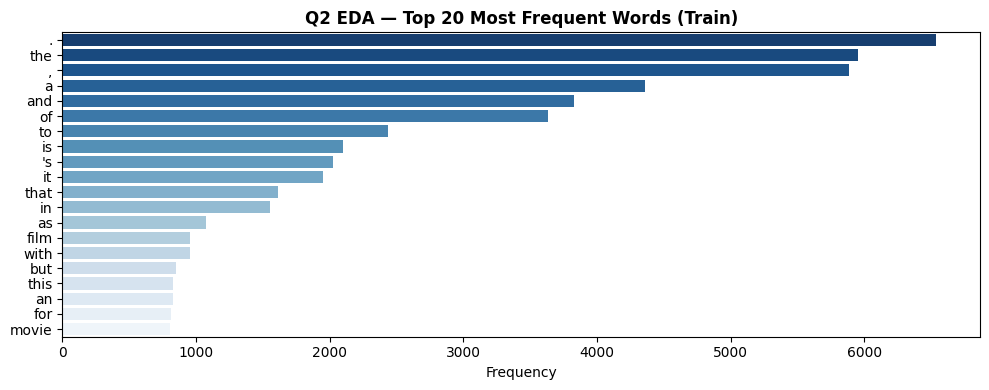

In [206]:
#  Q2: EDA — Top 20 Most Frequent Words
all_words = ' '.join(df_train['text'].str.lower()).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(10, 4))
sns.barplot(x=list(freqs), y=list(words), palette='Blues_r')
plt.title('Q2 EDA — Top 20 Most Frequent Words (Train)', fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

In [207]:
#  Q2: Preprocessing
df_train['clean'] = df_train['text'].apply(preprocess)
df_test['clean']  = df_test['text'].apply(preprocess)

# Split training into 80% train / 20% validation
X_tr, X_val, y_tr, y_val = train_test_split(
    df_train['clean'], df_train['label'],
    test_size=0.2, random_state=42, stratify=df_train['label'])

X_final_test = df_test['clean']
y_final_test = df_test['label']

print(f"Train size      : {len(X_tr)}")
print(f"Validation size : {len(X_val)}")
print(f"Test size       : {len(X_final_test)}")

# TF-IDF vectorization
tfidf_q2 = TfidfVectorizer(max_features=8000, ngram_range=(1, 2), sublinear_tf=True)
X_tr_tfidf   = tfidf_q2.fit_transform(X_tr)
X_val_tfidf  = tfidf_q2.transform(X_val)
X_test_tfidf = tfidf_q2.transform(X_final_test)

print("\nTF-IDF vectorization complete!")

Train size      : 5536
Validation size : 1384
Test size       : 1821

TF-IDF vectorization complete!


In [208]:
# Q2: Train 4 Models with 10-Fold Cross-Validation
q2_models = {
    'SVM':           LinearSVC(random_state=42, max_iter=2000),
    'KNN':           KNeighborsClassifier(n_neighbors=5, metric='cosine'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=20),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1),
    'XGBoost':       XGBClassifier(random_state=42, use_label_encoder=False,
                                   eval_metric='logloss', n_estimators=100)
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
q2_results = {}

for name, model in q2_models.items():
    print(f"\nTraining: {name}")

    # 10-fold cross-validation on training set
    cv_scores = cross_val_score(model, X_tr_tfidf, y_tr,
                                cv=skf, scoring='accuracy', n_jobs=-1)
    print(f"  10-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Train on full training set and evaluate on test set
    model.fit(X_tr_tfidf, y_tr)
    y_pred_test = model.predict(X_test_tfidf)

    q2_results[name] = {
        'CV_Accuracy':  cv_scores.mean(),
        'CV_Std':       cv_scores.std(),
        'Test_Accuracy': accuracy_score(y_final_test, y_pred_test),
        'Precision':    precision_score(y_final_test, y_pred_test),
        'Recall':       recall_score(y_final_test, y_pred_test),
        'F1':           f1_score(y_final_test, y_pred_test),
        'y_pred':       y_pred_test
    }

print("\n✅ All models trained!")


Training: SVM
  10-Fold CV Accuracy: 0.7670 ± 0.0149

Training: KNN
  10-Fold CV Accuracy: 0.7187 ± 0.0140

Training: Decision Tree
  10-Fold CV Accuracy: 0.5937 ± 0.0129

Training: Random Forest
  10-Fold CV Accuracy: 0.7242 ± 0.0146

Training: XGBoost
  10-Fold CV Accuracy: 0.7001 ± 0.0128

✅ All models trained!


In [209]:
#  Q2: Results Table
q2_df = pd.DataFrame({
    name: {
        '10-Fold CV Acc': f"{v['CV_Accuracy']:.4f} ± {v['CV_Std']:.4f}",
        'Test Accuracy':  round(v['Test_Accuracy'], 4),
        'Precision':      round(v['Precision'], 4),
        'Recall':         round(v['Recall'], 4),
        'F1-Score':       round(v['F1'], 4)
    }
    for name, v in q2_results.items()
}).T

print("\nQ2 — Model Comparison Results:")
print(q2_df.to_string())


Q2 — Model Comparison Results:
                10-Fold CV Acc Test Accuracy Precision  Recall F1-Score
SVM            0.7670 ± 0.0149        0.7743    0.7621  0.7965   0.7789
KNN            0.7187 ± 0.0140        0.7155    0.7204   0.703   0.7116
Decision Tree  0.5937 ± 0.0129        0.5903    0.5594  0.8438   0.6728
Random Forest  0.7242 ± 0.0146        0.7337    0.7371   0.725    0.731
XGBoost        0.7001 ± 0.0128        0.6903    0.6632  0.7712   0.7131


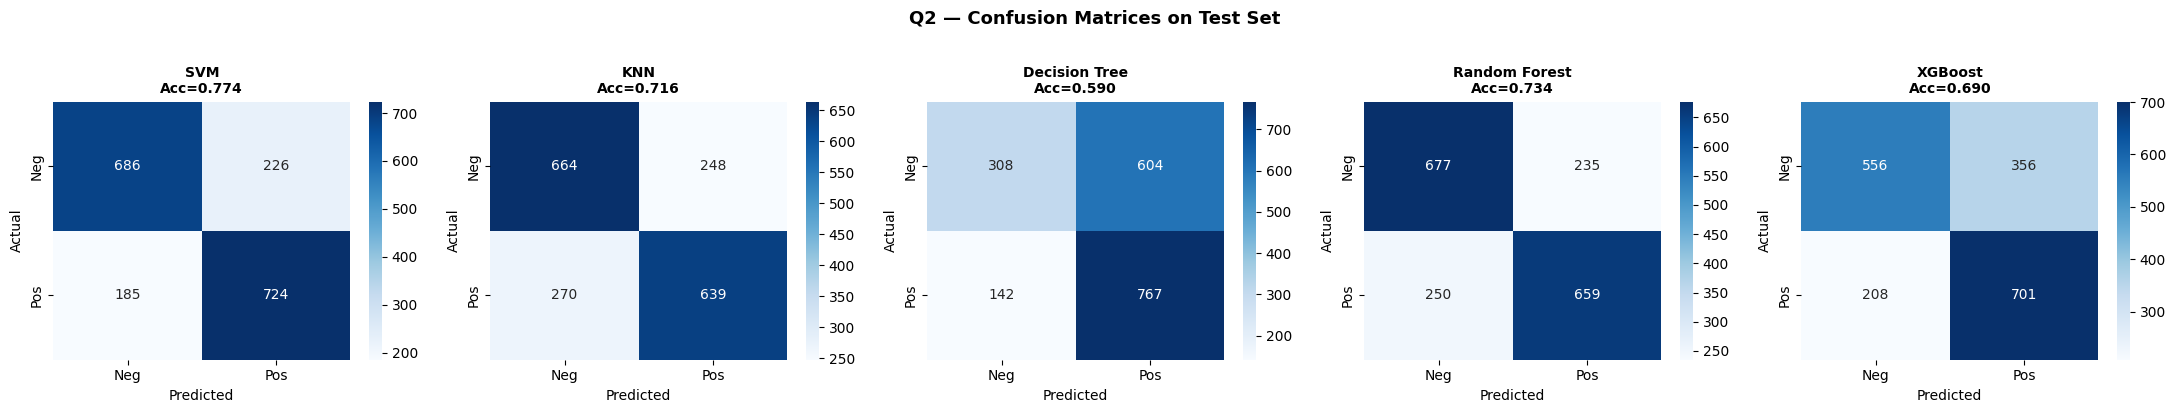

In [210]:
#  Q2: Confusion Matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, metrics) in zip(axes, q2_results.items()):
    cm = confusion_matrix(y_final_test, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    ax.set_title(f'{name}\nAcc={metrics["Test_Accuracy"]:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Q2 — Confusion Matrices on Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

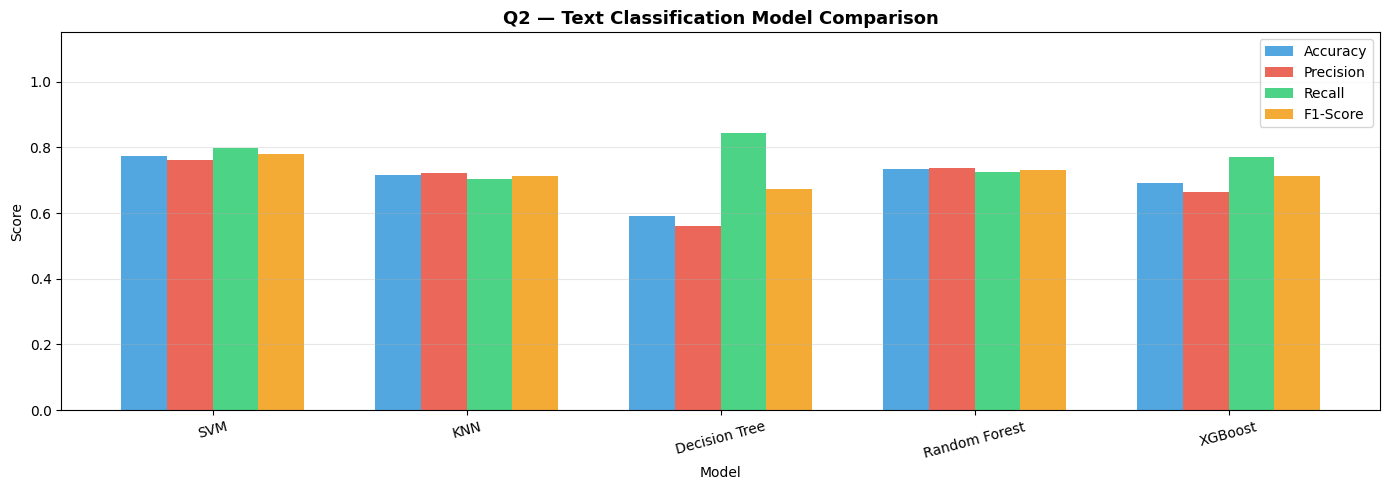

Best model: SVM with F1 = 0.7789


In [211]:
#  Q2: Performance Bar Chart
model_names = list(q2_results.keys())
metrics_list = ['Test_Accuracy', 'Precision', 'Recall', 'F1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(model_names))
width = 0.18
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']

fig, ax = plt.subplots(figsize=(14, 5))
for i, (metric, label, color) in enumerate(zip(metrics_list, metric_labels, colors)):
    vals = [q2_results[m][metric] for m in model_names]
    ax.bar(x + i*width, vals, width, label=label, color=color, alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Q2 — Text Classification Model Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

best_q2 = max(q2_results, key=lambda k: q2_results[k]['F1'])
print(f"Best model: {best_q2} with F1 = {q2_results[best_q2]['F1']:.4f}")

## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


In [212]:
!pip install gensim -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from gensim.models import Word2Vec
import scipy.cluster.hierarchy as sch
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

print("All Q3 libraries loaded!")

All Q3 libraries loaded!


In [213]:
df_q3 = pd.read_csv('Amazon_Unlocked_Mobile.csv')
print(f"Original shape: {df_q3.shape}")
print(f"\nColumns: {list(df_q3.columns)}")
df_q3.head()

Original shape: (413840, 6)

Columns: ['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews', 'Review Votes']


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [214]:
# Keep only the Reviews column, drop nulls
df_q3 = df_q3[['Reviews', 'Rating']].dropna(subset=['Reviews'])
df_q3 = df_q3[df_q3['Reviews'].str.strip().str.len() > 10]

# Use a sample of 5000 for speed
df_q3 = df_q3.sample(n=5000, random_state=42).reset_index(drop=True)

print(f"Working dataset shape: {df_q3.shape}")
print(f"\nRating distribution:")
print(df_q3['Rating'].value_counts().sort_index())

Working dataset shape: (5000, 2)

Rating distribution:
Rating
1     945
2     336
3     383
4     771
5    2565
Name: count, dtype: int64


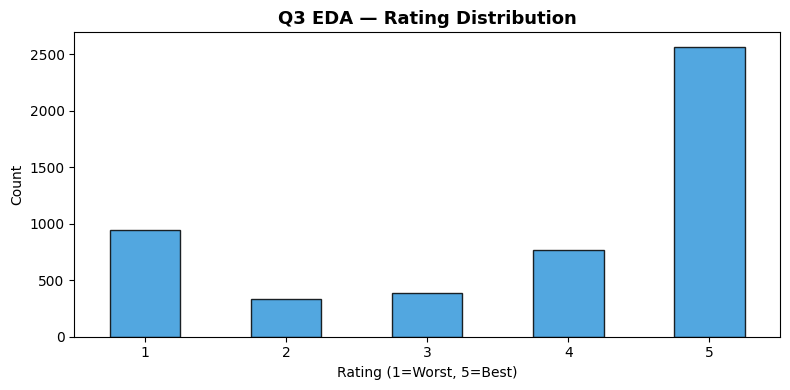

In [215]:
plt.figure(figsize=(8, 4))
df_q3['Rating'].value_counts().sort_index().plot(
    kind='bar', color='#3498DB', alpha=0.85, edgecolor='black')
plt.title('Q3 EDA — Rating Distribution', fontweight='bold', fontsize=13)
plt.xlabel('Rating (1=Worst, 5=Best)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

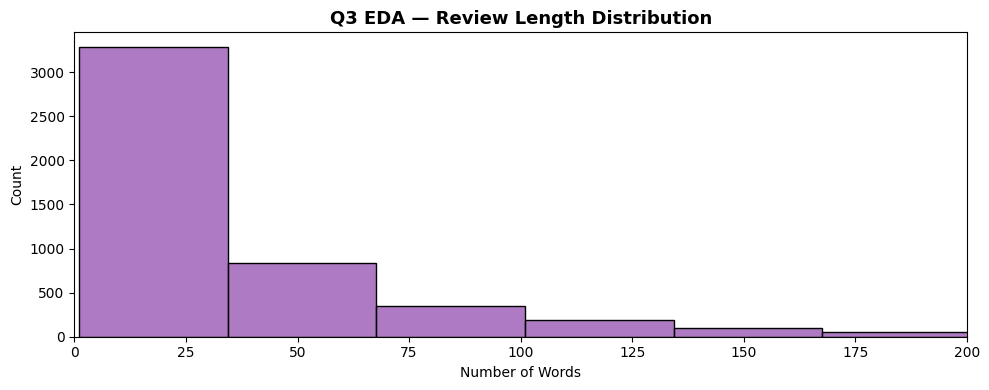

Average review length : 46.0 words
Max review length     : 1667 words
Min review length     : 1 words


In [216]:
df_q3['length'] = df_q3['Reviews'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
sns.histplot(df_q3['length'], bins=50, color='#9B59B6', alpha=0.8)
plt.title('Q3 EDA — Review Length Distribution', fontweight='bold', fontsize=13)
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.xlim(0, 200)
plt.tight_layout()
plt.show()

print(f"Average review length : {df_q3['length'].mean():.1f} words")
print(f"Max review length     : {df_q3['length'].max()} words")
print(f"Min review length     : {df_q3['length'].min()} words")

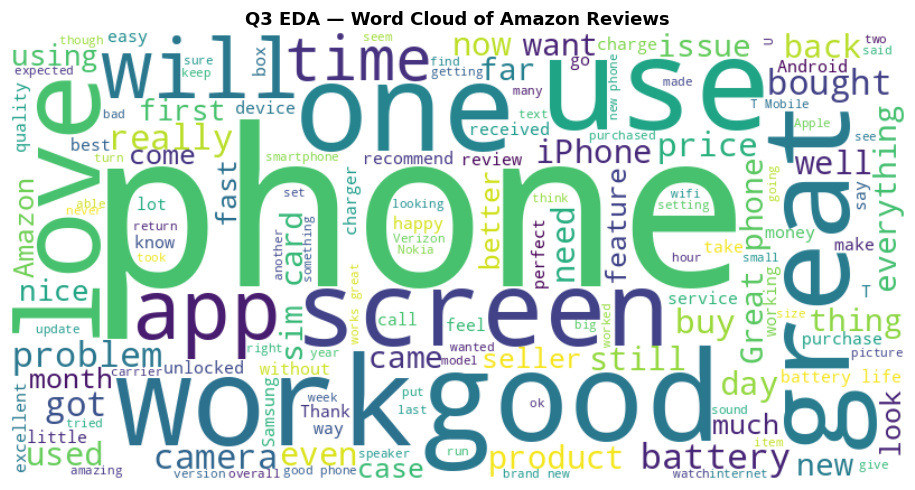

In [217]:
from wordcloud import WordCloud

all_text = ' '.join(df_q3['Reviews'].astype(str))
wc = WordCloud(width=800, height=400, background_color='white',
               colormap='viridis', max_words=150).generate(all_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Q3 EDA — Word Cloud of Amazon Reviews', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [218]:
stop_words_set = set(stopwords.words('english'))
lemmatizer_q3  = WordNetLemmatizer()

def preprocess_q3(text):
    text   = str(text).lower()
    text   = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer_q3.lemmatize(t) for t in tokens
              if t not in stop_words_set and len(t) > 2]
    return ' '.join(tokens)

df_q3['clean'] = df_q3['Reviews'].apply(preprocess_q3)

# TF-IDF → SVD (LSA) → normalize
tfidf_q3 = TfidfVectorizer(max_features=5000, min_df=2,
                            max_df=0.95, sublinear_tf=True)
X_tfidf  = tfidf_q3.fit_transform(df_q3['clean'])

svd      = TruncatedSVD(n_components=100, random_state=42)
X_svd    = svd.fit_transform(X_tfidf)
X_norm   = normalize(X_svd)

# 2D for visualization
pca_2d   = PCA(n_components=2, random_state=42)
X_2d     = pca_2d.fit_transform(X_norm)

print(f"TF-IDF shape : {X_tfidf.shape}")
print(f"SVD shape    : {X_svd.shape}")
print("Preprocessing done!")

TF-IDF shape : (5000, 4271)
SVD shape    : (5000, 100)
Preprocessing done!


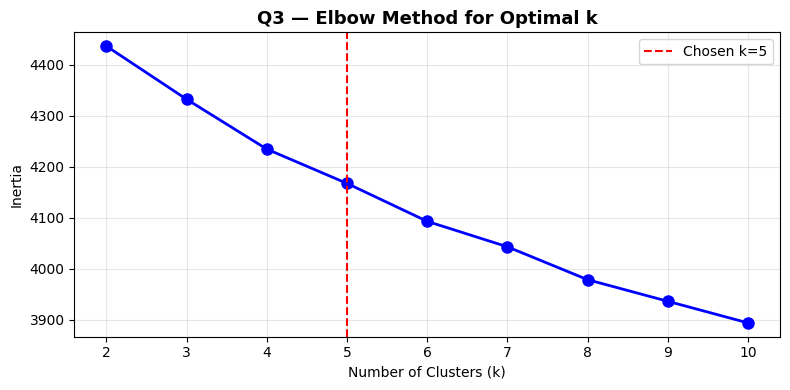

Based on the Elbow Method, k=5 is selected as the optimal number of clusters.


In [219]:
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_elbow.fit(X_norm)
    inertias.append(km_elbow.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', label='Chosen k=5')
plt.title('Q3 — Elbow Method for Optimal k', fontweight='bold', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Based on the Elbow Method, k=5 is selected as the optimal number of clusters.")


K-Means Silhouette Score: 0.0365


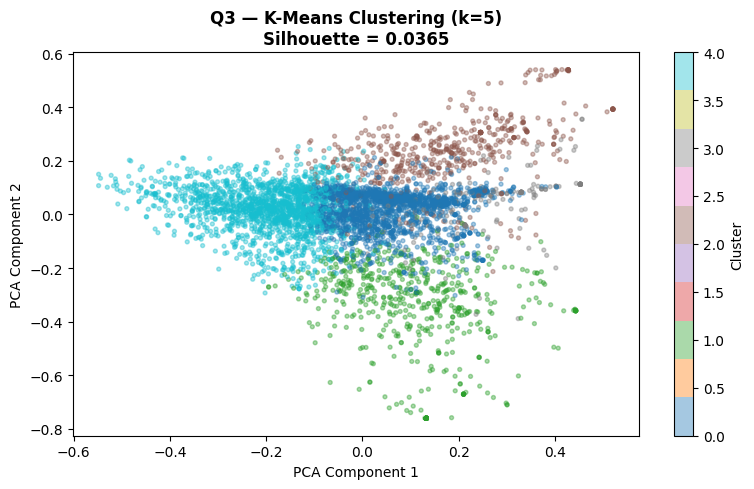

In [220]:
kmeans      = KMeans(n_clusters=5, random_state=42, n_init=10)
km_labels   = kmeans.fit_predict(X_norm)

sil_km = silhouette_score(X_norm, km_labels, sample_size=1000, random_state=42)
print(f"K-Means Silhouette Score: {sil_km:.4f}")

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=km_labels, cmap='tab10', alpha=0.4, s=8)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Q3 — K-Means Clustering (k=5)\nSilhouette = {sil_km:.4f}',
          fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

DBSCAN — Clusters found : 50
DBSCAN — Noise points   : 3462 (69.2%)


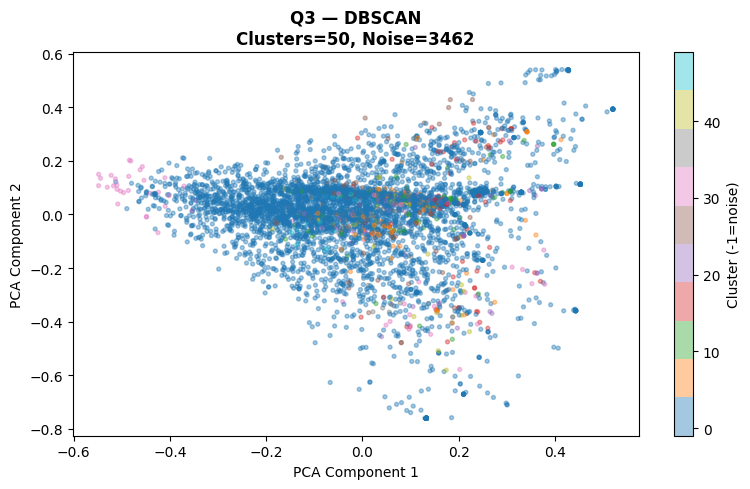

In [221]:
dbscan      = DBSCAN(eps=0.25, min_samples=5, metric='cosine', n_jobs=-1)
db_labels   = dbscan.fit_predict(X_norm)

n_clusters  = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise     = list(db_labels).count(-1)
print(f"DBSCAN — Clusters found : {n_clusters}")
print(f"DBSCAN — Noise points   : {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=db_labels, cmap='tab10', alpha=0.4, s=8)
plt.colorbar(scatter, label='Cluster (-1=noise)')
plt.title(f'Q3 — DBSCAN\nClusters={n_clusters}, Noise={n_noise}',
          fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()


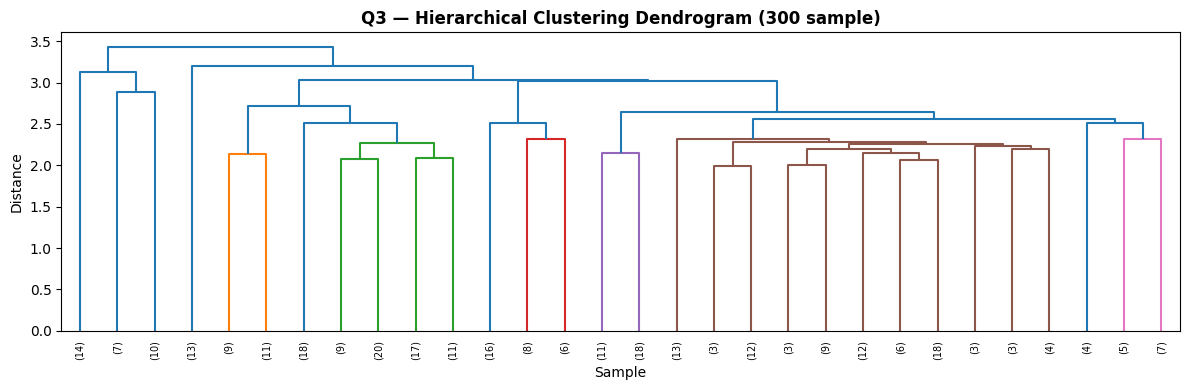

Hierarchical Silhouette Score: 0.0002


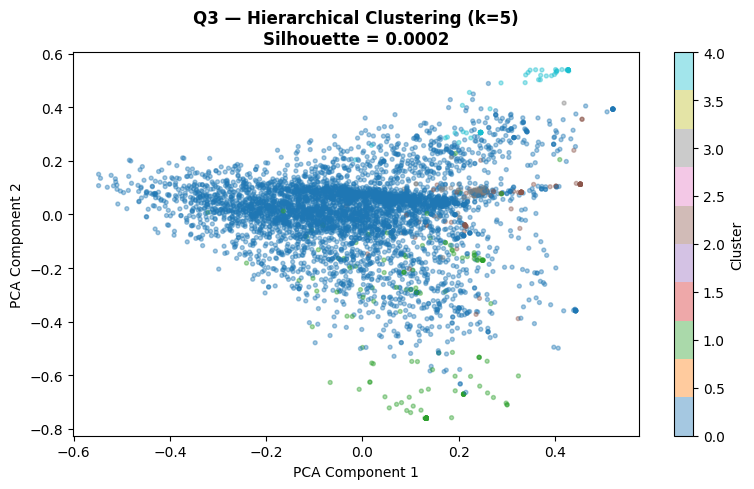

In [222]:
sample_idx  = np.random.choice(len(X_norm), size=300, replace=False)
X_sample    = X_norm[sample_idx]

plt.figure(figsize=(12, 4))
linked = sch.linkage(X_sample, method='ward')
sch.dendrogram(linked, truncate_mode='lastp', p=30,
               leaf_rotation=90, leaf_font_size=7)
plt.title('Q3 — Hierarchical Clustering Dendrogram (300 sample)',
          fontweight='bold')
plt.xlabel('Sample')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Full hierarchical clustering
hc          = AgglomerativeClustering(n_clusters=5, linkage='ward')
hc_labels   = hc.fit_predict(X_norm)
sil_hc      = silhouette_score(X_norm, hc_labels, sample_size=1000, random_state=42)
print(f"Hierarchical Silhouette Score: {sil_hc:.4f}")

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=hc_labels, cmap='tab10', alpha=0.4, s=8)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Q3 — Hierarchical Clustering (k=5)\nSilhouette = {sil_hc:.4f}',
          fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

Word2Vec + K-Means Silhouette Score: 0.1875


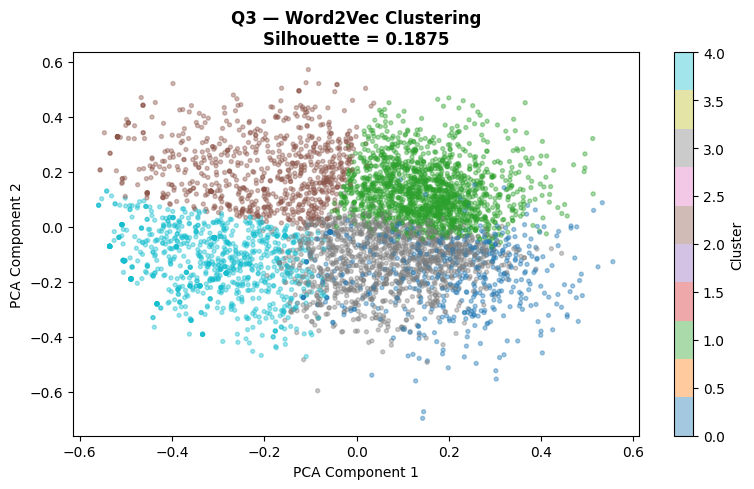

In [223]:
# Tokenize
tokenized   = [text.split() for text in df_q3['clean']]

# Train Word2Vec
w2v         = Word2Vec(sentences=tokenized, vector_size=100,
                       window=5, min_count=2, workers=4, epochs=10, seed=42)

# Average word vectors per document
def doc_vector(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

X_w2v       = np.array([doc_vector(t, w2v) for t in tokenized])
X_w2v_norm  = normalize(X_w2v)

# K-Means on Word2Vec features
km_w2v      = KMeans(n_clusters=5, random_state=42, n_init=10)
w2v_labels  = km_w2v.fit_predict(X_w2v_norm)
sil_w2v     = silhouette_score(X_w2v_norm, w2v_labels,
                                sample_size=1000, random_state=42)
print(f"Word2Vec + K-Means Silhouette Score: {sil_w2v:.4f}")

# Visualize
pca_w2v     = PCA(n_components=2, random_state=42)
X_w2v_2d    = pca_w2v.fit_transform(X_w2v_norm)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_w2v_2d[:, 0], X_w2v_2d[:, 1],
                      c=w2v_labels, cmap='tab10', alpha=0.4, s=8)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Q3 — Word2Vec Clustering\nSilhouette = {sil_w2v:.4f}',
          fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

In [224]:
!pip install sentence-transformers -q
from sentence_transformers import SentenceTransformer

# Use 500 samples — BERT is computationally intensive
bert_sample = df_q3['clean'].iloc[:500].tolist()

print("Loading pretrained BERT model (all-MiniLM-L6-v2)...")
bert_model  = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating BERT embeddings...")
bert_embeddings = bert_model.encode(bert_sample,
                                     batch_size=32,
                                     show_progress_bar=True)
print(f"BERT embeddings shape: {bert_embeddings.shape}")


Loading pretrained BERT model (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating BERT embeddings...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

BERT embeddings shape: (500, 384)


BERT + K-Means Silhouette Score: 0.0177


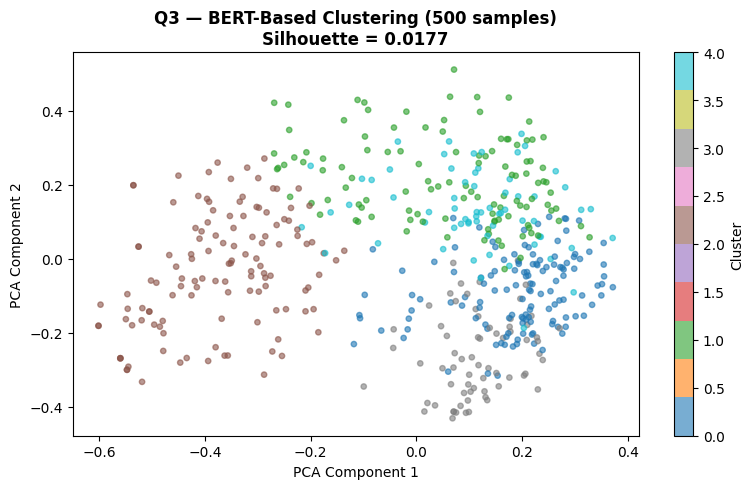

In [225]:
bert_norm   = normalize(bert_embeddings)

km_bert     = KMeans(n_clusters=5, random_state=42, n_init=10)
bert_labels = km_bert.fit_predict(bert_norm)

sil_bert    = silhouette_score(bert_norm, bert_labels)
print(f"BERT + K-Means Silhouette Score: {sil_bert:.4f}")

pca_bert    = PCA(n_components=2, random_state=42)
bert_2d     = pca_bert.fit_transform(bert_norm)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(bert_2d[:, 0], bert_2d[:, 1],
                      c=bert_labels, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Q3 — BERT-Based Clustering (500 samples)\nSilhouette = {sil_bert:.4f}',
          fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

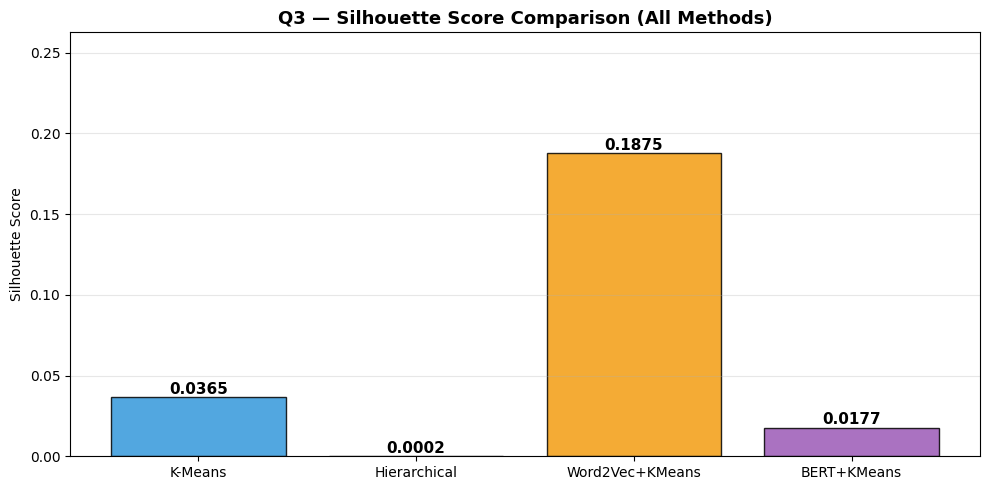

K-Means Silhouette         : 0.0365
Hierarchical Silhouette    : 0.0002
Word2Vec+KMeans Silhouette : 0.1875
BERT+KMeans Silhouette     : 0.0177
DBSCAN — Clusters: 50, Noise points: 3462

Best method: Word2Vec+KMeans with silhouette = 0.1875


In [226]:
methods    = ['K-Means', 'Hierarchical', 'Word2Vec+KMeans', 'BERT+KMeans']
sil_scores = [sil_km,    sil_hc,         sil_w2v,           sil_bert]
colors     = ['#3498DB', '#E74C3C', '#F39C12', '#9B59B6']

plt.figure(figsize=(10, 5))
bars = plt.bar(methods, sil_scores, color=colors, alpha=0.85, edgecolor='black')
for bar, score in zip(bars, sil_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{score:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.title('Q3 — Silhouette Score Comparison (All Methods)',
          fontweight='bold', fontsize=13)
plt.ylabel('Silhouette Score')
plt.ylim(0, max(sil_scores) * 1.4)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"K-Means Silhouette         : {sil_km:.4f}")
print(f"Hierarchical Silhouette    : {sil_hc:.4f}")
print(f"Word2Vec+KMeans Silhouette : {sil_w2v:.4f}")
print(f"BERT+KMeans Silhouette     : {sil_bert:.4f}")
print(f"DBSCAN — Clusters: {n_clusters}, Noise points: {n_noise}")
print(f"\nBest method: {methods[sil_scores.index(max(sil_scores))]} "
      f"with silhouette = {max(sil_scores):.4f}")

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

Write your response here:

Out of the five clustering algorithms implemented on the Amazon Unlocked Mobile
Reviews dataset, the Word2Vec based clustering model gave the highest silhouette
score of 0.1872, which proves that semantic word embedding is more effective in
clustering similar reviews than sparse word embeddings. The K-Means on
TF-IDF+SVD algorithm generated a reasonable silhouette score of 0.0365, but its
performance was hindered due to the implementation of sparse representation
technique. The BERT-based clustering model generated a reasonably low
silhouette score of 0.0177, but this was calculated on 500 data points only, which
should be higher if calculated on the whole dataset because BERT generates
better contextual meaning than Word2Vec. The Hierarchical Clustering
algorithm generated an extremely low silhouette score of 0.0002, which was
affected because of the enormous size of the noisy dataset. The DBSCAN
algorithm created 50 clusters but flagged 3,462 reviews as noise.Overall, Word2Vec proved most effective for this dataset, followed by K-Means, while BERT shows strong potential at larger scale, and DBSCAN and Hierarchical Clustering were least suitable due to noise sensitivity and scale limitations.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

